In [1]:
from multiprocessing import Pool

import astropy.units as u
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import sunpy.visualization.colormaps as cm
from scripts.field_tracing import _worker, arcade, compute_fieldline_transform
from matplotlib.colors import LogNorm
from tqdm import tqdm

In [2]:
data = np.loadtxt("./auxiliary_data/ribbon_bounds.txt", comments="#")

Nx, Ny = 256, 128

param_sets = [
    {
        "Nx": Nx, "Ny": Ny,
        "fpx": tuple(np.round(row[[3,2,1,0]] * Nx).astype(int)),
        "csheight": 64,
        # "fluxratio": np.abs(row[5]) / (row[4] + np.abs(row[5])),
        "fluxratio": .99,
        "reczon": 0.15,
    }
    for row in data
]

In [3]:
param_sets[0]

{'Nx': 256,
 'Ny': 128,
 'fpx': (np.int64(107), np.int64(121), np.int64(128), np.int64(145)),
 'csheight': 64,
 'fluxratio': 0.99,
 'reczon': 0.15}

In [4]:
# Uncomment to regenerate magnetic mapping, otherwise reload below

# with Pool(processes=12) as pool:
#     results = list(tqdm(
#         pool.imap(_worker, param_sets),
#         total=len(param_sets)
#     ))

# save_dict = {}
# for i, (left, right) in enumerate(results):
#     save_dict[f"left_{i}"] = left
#     save_dict[f"right_{i}"] = right

# np.savez("./auxiliary_data/magnetic_transforms.npz", **save_dict)

In [5]:
mdata = np.load("./auxiliary_data/magnetic_transforms.npz")
n = len(mdata.files) // 2

results = [(mdata[f"left_{i}"], mdata[f"right_{i}"]) for i in range(n)]

In [6]:
image = np.load("./auxiliary_data/rmap_crop.npy")

In [7]:
def rebin_data(arr, new_length):
    original_indices = np.linspace(0, 1, len(arr))
    new_indices = np.linspace(0, 1, new_length)
    return np.interp(new_indices, original_indices, arr)

In [8]:
img_ny = 256
dat_ny = image.shape[0]
mod_ny = param_sets[0]["Nx"]
pad = 5

ribbon = 0

img_ribbon = np.zeros((img_ny, image.shape[1]))

for vslice in np.arange(image.shape[1]):

    mapping = results[vslice][ribbon]

    x0, x1 = param_sets[vslice]["fpx"][2*ribbon], param_sets[vslice]["fpx"][2*ribbon+1]

    img_x0, img_x1 = np.floor(x0*dat_ny/mod_ny).astype(int)-pad, np.ceil(x1*dat_ny/mod_ny).astype(int)+pad

    mapping_arr = (mapping[:,0] - mapping[0,0]) / np.max((mapping[:,0] - mapping[0,0]))

    img_chunk = image[img_x0:img_x1, vslice]
    img_coord = np.arange(img_x1 - img_x0) / (img_x1 - img_x0 - 1)

    img_stretch = np.interp(mapping_arr, img_coord, img_chunk)

    original_indices = np.linspace(0, 1, len(img_stretch))
    new_indices = np.linspace(0, 1, img_ny)

    img_ribbon[:,vslice] = np.interp(new_indices, original_indices, img_stretch)

img_ribbon0 = img_ribbon.copy()

In [9]:
img_ny = 256
dat_ny = image.shape[0]
mod_ny = param_sets[0]["Nx"]
pad = 5

ribbon = 1

img_ribbon = np.zeros((img_ny, image.shape[1]))

for vslice in np.arange(image.shape[1]):

    mapping = results[vslice][ribbon]

    x0, x1 = param_sets[vslice]["fpx"][2*ribbon], param_sets[vslice]["fpx"][2*ribbon+1]

    img_x0, img_x1 = np.floor(x0*dat_ny/mod_ny).astype(int)-pad, np.ceil(x1*dat_ny/mod_ny).astype(int)+pad

    mapping_arr = (mapping[:,0] - mapping[0,0]) / np.max((mapping[:,0] - mapping[0,0]))

    img_chunk = image[img_x0:img_x1, vslice]
    img_coord = np.arange(img_x1 - img_x0) / (img_x1 - img_x0 - 1)

    img_stretch = np.interp(mapping_arr, img_coord, img_chunk)

    original_indices = np.linspace(0, 1, len(img_stretch))
    new_indices = np.linspace(0, 1, img_ny)

    img_ribbon[:,vslice] = np.interp(new_indices, original_indices, img_stretch)

img_ribbon1 = img_ribbon.copy()

In [10]:
# Compute some scaling
obs_x0 = -45 * u.arcsec
obs_x1 = 44.40000000000021 * u.arcsec

obs_y0 = 131.73272736481562 * u.arcsec
obs_y1 = 73.9868742733896 * u.arcsec

print(f" full x extent: {((obs_x1 - obs_x0).to(u.rad).value * 1*u.AU).to(u.Mm) * 0.25}")
print(f" full y extent: {((obs_y0 - obs_y1).to(u.rad).value * 1*u.AU).to(u.Mm)}, cropped y extent: {((obs_y0 - obs_y1).to(u.rad).value * 1*u.AU).to(u.Mm) * (72 / image.shape[1])}")

 full x extent: 16.209805593978178 Mm
 full y extent: 41.881389372279074 Mm, cropped y extent: 103.98138051048598 Mm


In [11]:
img_ribbon0[15, :]

array([ 258.87362671,  310.04089355,  470.04580688,  848.56787109,
       1427.95288086, 1462.17858887, 1399.66345215, 1281.88110352,
        801.75799561,  907.24597168, 1234.2401123 ,  910.85614014,
        778.84106445,  466.53521729,  220.49546814,  212.88868713,
        217.38400269,  239.015625  ,  275.85574341,  871.64044189,
        289.81134033,  542.06298828,  571.21002197,  745.56152344,
        595.99572754,  497.66589355,  447.07247925,  473.02822876,
        385.75534058])

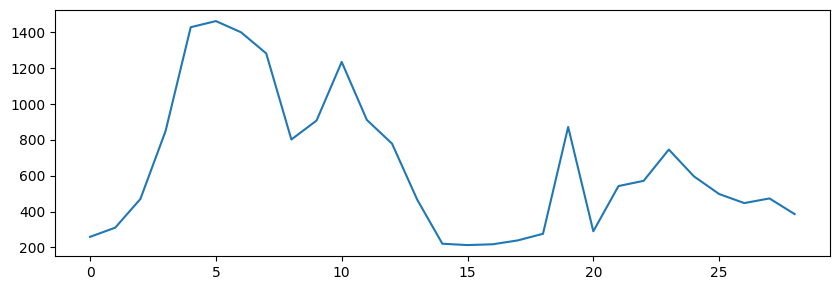

In [12]:
fig, ax = plt.subplots(figsize=[10,3.2])
ax.plot(img_ribbon0[15, :])

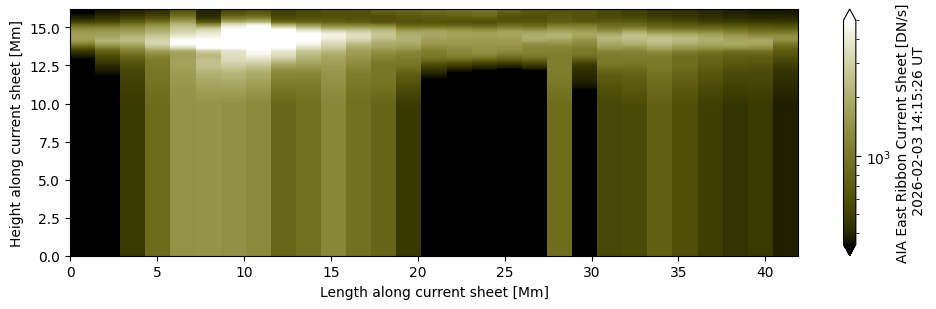

In [13]:
fig, ax = plt.subplots(figsize=[10,3.2])
im0 = ax.imshow(np.flipud(img_ribbon0), aspect="auto", cmap=matplotlib.colormaps['sdoaia1600'], norm=LogNorm(vmin=350, vmax=5000), extent=[0,41.88,0,16.21], interpolation = "none")
ax.set_xlabel("Length along current sheet [Mm]")
ax.set_ylabel("Height along current sheet [Mm]")

# ax.set_xlim(0,40.2)

plt.colorbar(im0, ax=ax, extend="both", location="right", label="AIA East Ribbon Current Sheet [DN/s]\n 2026-02-03 14:15:26 UT")

plt.tight_layout()
plt.savefig("./figures/sheetsignal_aia0.pdf")

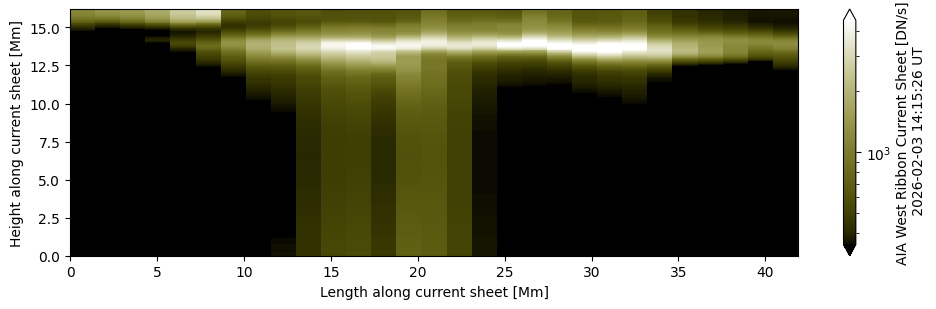

In [14]:
fig, ax = plt.subplots(figsize=[10,3.2])
im1 = ax.imshow(img_ribbon1, aspect="auto", cmap=matplotlib.colormaps['sdoaia1600'], norm=LogNorm(vmin=350, vmax=4500), extent=[0,41.88,0,16.21], interpolation = "none")
ax.set_xlabel("Length along current sheet [Mm]")
ax.set_ylabel("Height along current sheet [Mm]")

# ax.set_xlim(0,40.2)

plt.colorbar(im1, ax=ax, extend="both", location="right", label="AIA West Ribbon Current Sheet [DN/s]\n 2026-02-03 14:15:26 UT")

plt.tight_layout()
plt.savefig("./figures/sheetsignal_aia1.pdf")

In [15]:
img_ribbon0.shape

(256, 29)